# Noise and Filtering

### Prediction

I expect the Median filter to preserve text edges best.
##### Reason
* Mean and Gaussian filters smooth the image by averaging neighboring pixels, which tends to blur sharp text boundaries.
* Median filtering replaces each pixel with the median value in its neighborhood, which is known for  preserving edges better while removing noise.
* Bilateral filtering also preserves edges by considering both spatial distance and pixel intensity differences, so it may perform very well.
* However, since the added noise is Gaussian, I predict Median filter will retain the sharpest text edges.

### Import the Required Libraries

In [33]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

### Load Text-Page Photo

In [35]:
image = cv2.imread("Documents/AIML-Assessment/Module-2/raw_captures/Capture_4.jpeg",cv2.IMREAD_GRAYSCALE)

### Add Gaussian Noise

In [36]:
mean = 0
sigma = 25
gaussian_noise = np.random.normal(mean, sigma, image.shape)
noisy_image = image.astype(np.float32) + gaussian_noise
noisy_image = np.clip(noisy_image, 0, 255).astype(np.uint8)

### Apply Mean Filter

In [37]:
mean_filtered = cv2.blur(noisy_image, (5,5))

### Apply Gaussian Filter

In [38]:
gaussian_filtered = cv2.GaussianBlur(image, (5,5), 0)

### Apply Median Filter

In [39]:
median_filtered = cv2.medianBlur(image, 5)

### Apply Bilateral Filter

In [40]:
bilateral_filtered = cv2.bilateralFilter(image,9,75,75)

### Display the Results

Text(0.5, 1.0, 'Bilateral')

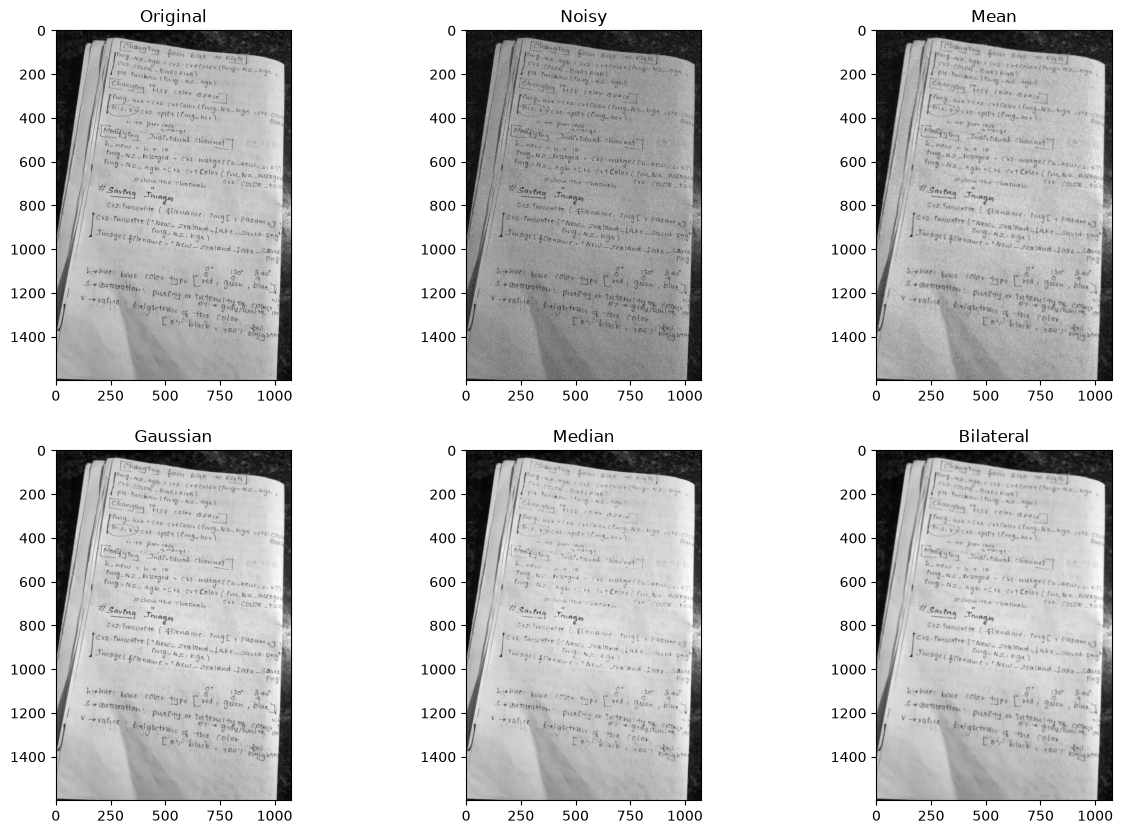

In [42]:
fig, axes = plt.subplots(2,3,figsize=(15,10))
axes[0][0].imshow(image, cmap="gray")
axes[0][0].set_title("Original")
axes[0][1].imshow(noisy_image, cmap="gray")
axes[0][1].set_title("Noisy")
axes[0][2].imshow(mean_filtered, cmap="gray")
axes[0][2].set_title("Mean")
axes[1][0].imshow(gaussian_filtered, cmap="gray")
axes[1][0].set_title("Gaussian")
axes[1][1].imshow(median_filtered, cmap="gray")
axes[1][1].set_title("Median")
axes[1][2].imshow(bilateral_filtered,  cmap="gray")
axes[1][2].set_title("Bilateral")

### Note

Before filtering, I predicted that the Median filter would preserve text edges best because it is known for edge preservation. However, after applying the filters, the Gaussian filter produced clearer handwritten text than the Median filter. The Median filter removed noise effectively but also reduced some fine text details. The Bilateral filter achieved the best overall balance between noise reduction and edge preservation. This showed that the effectiveness of a filter depends on both the noise type and the characteristics of the image.